# 第060讲 Bagging与随机森林

从bootstrap编号开始，检查平均的分母、OOB资格和群组边界。先完成五行手算表，再运行。本Notebook使用离线原创数据。

In [1]:
from pathlib import Path
import json
import numpy as np
from experiment import run
from common import write_json
result=run()
write_json('outputs/notebook-result.json',result)
print(result['selection'])

{'max_features': 3, 'B': 80, 'criterion': 'minimum full-coverage OOB Brier among m=1,3,8; ties lower m', 'selected_before_test_read': True}


## 抽样成员是OOB的依据
每棵树抽360次，不代表360个不同对象。零计数才表示该行对这棵树袋外。

In [2]:
samples=np.array(result['ensembles']['3']['bootstrap_samples'])
counts=np.bincount(samples[0],minlength=360)
print('draws:',counts.sum(),'unique:',np.count_nonzero(counts),'OOB:',sum(counts==0))
print(result['bootstrap_theory'])

draws: 360 unique: 233 OOB: 127
{'row_absent_probability': 0.3673679053105327, 'expected_unique': 227.7475540882082}


## 特征数与树数
最终特征数只用80树OOB选取。测试曲线为预先声明的机制比较，不拿来继续选模型。

In [3]:
for m,row in result['ensembles'].items():
    print('m=',m,'test curves=',row['curves'])
    print('OOB coverage=',[(q['B'],q['coverage']) for q in row['oob']])

m= 1 test curves= [{'accuracy': 0.5777777777777777, 'brier': 0.34656404320987655, 'B': 1}, {'accuracy': 0.6777777777777778, 'brier': 0.22302745338876295, 'B': 5}, {'accuracy': 0.7472222222222222, 'brier': 0.18328173469387754, 'B': 20}, {'accuracy': 0.7555555555555555, 'brier': 0.18341274884997405, 'B': 80}]
OOB coverage= [(1, 0.3527777777777778), (5, 0.9111111111111111), (20, 1.0), (80, 1.0)]
m= 3 test curves= [{'accuracy': 0.6694444444444444, 'brier': 0.30773225308641977, 'B': 1}, {'accuracy': 0.7194444444444444, 'brier': 0.20367046296296298, 'B': 5}, {'accuracy': 0.7611111111111111, 'brier': 0.1706248128858025, 'B': 20}, {'accuracy': 0.7666666666666667, 'brier': 0.16959312258381362, 'B': 80}]
OOB coverage= [(1, 0.3527777777777778), (5, 0.9111111111111111), (20, 1.0), (80, 1.0)]
m= 8 test curves= [{'accuracy': 0.7027777777777777, 'brier': 0.2746211419753086, 'B': 1}, {'accuracy': 0.7583333333333333, 'brier': 0.19188694444444446, 'B': 5}, {'accuracy': 0.7611111111111111, 'brier': 0.180

## 独立审计
重建所有bootstrap树，逐行重算袋外概率；同时核对库聚合、方差恒等式和群组反例。

In [4]:
from test_experiment import audit
checks=audit(result)
print(checks['status'],checks['checks'])

passed 859


## 重新绘图
图2的固定输入重复方差模型与图5跨测试行残差相关不同，不直接互相代入。

01_bootstrap.png


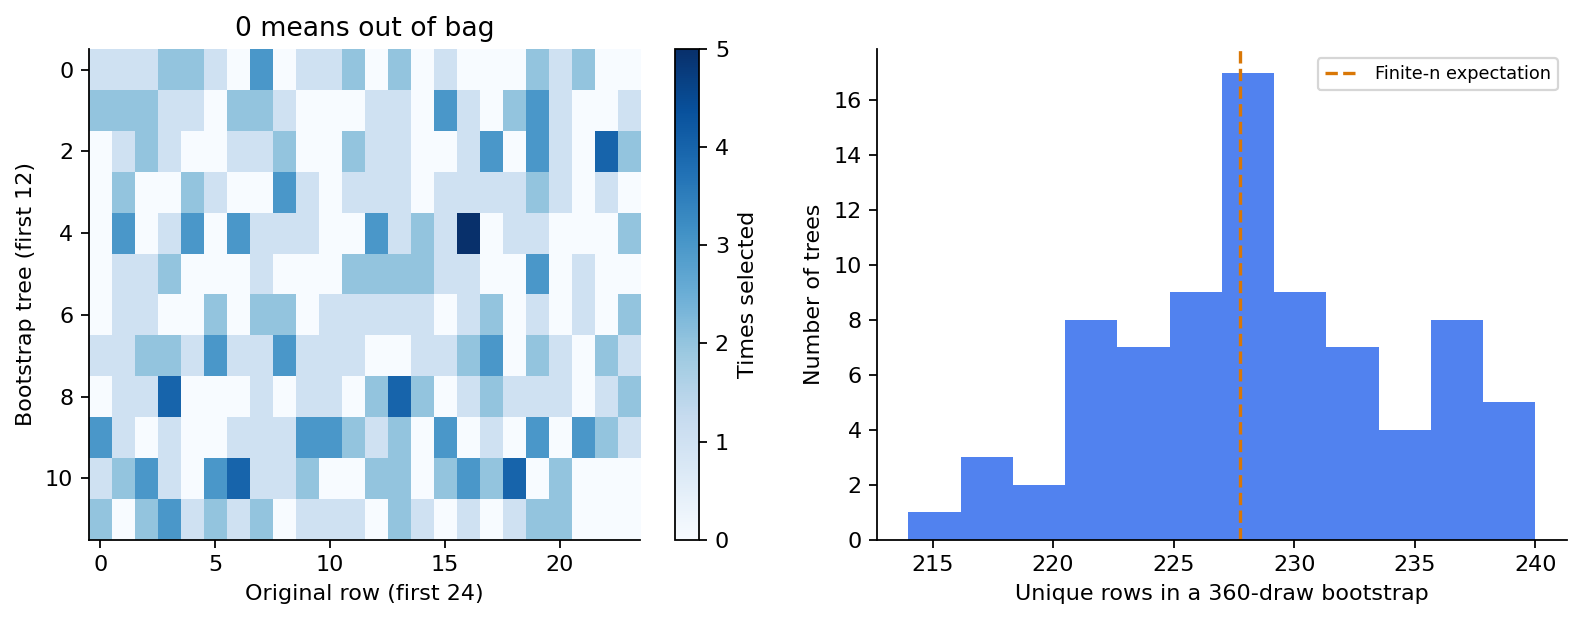

02_variance.png


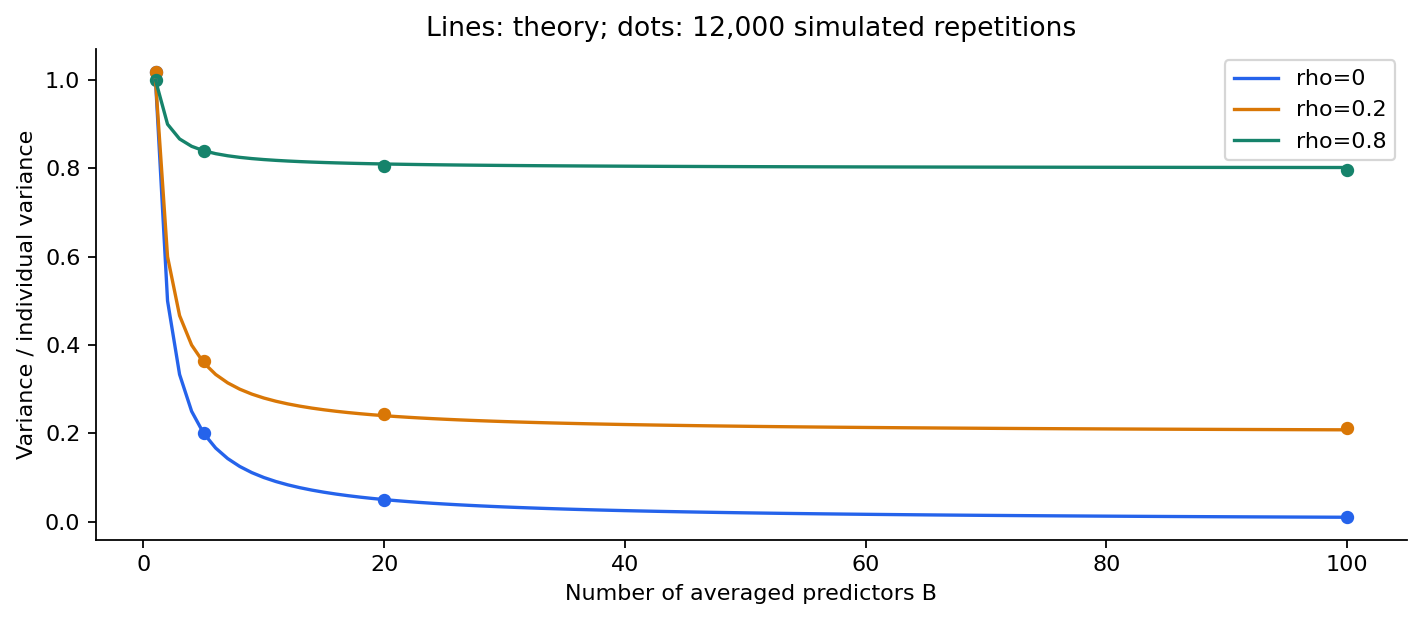

03_learning_curves.png


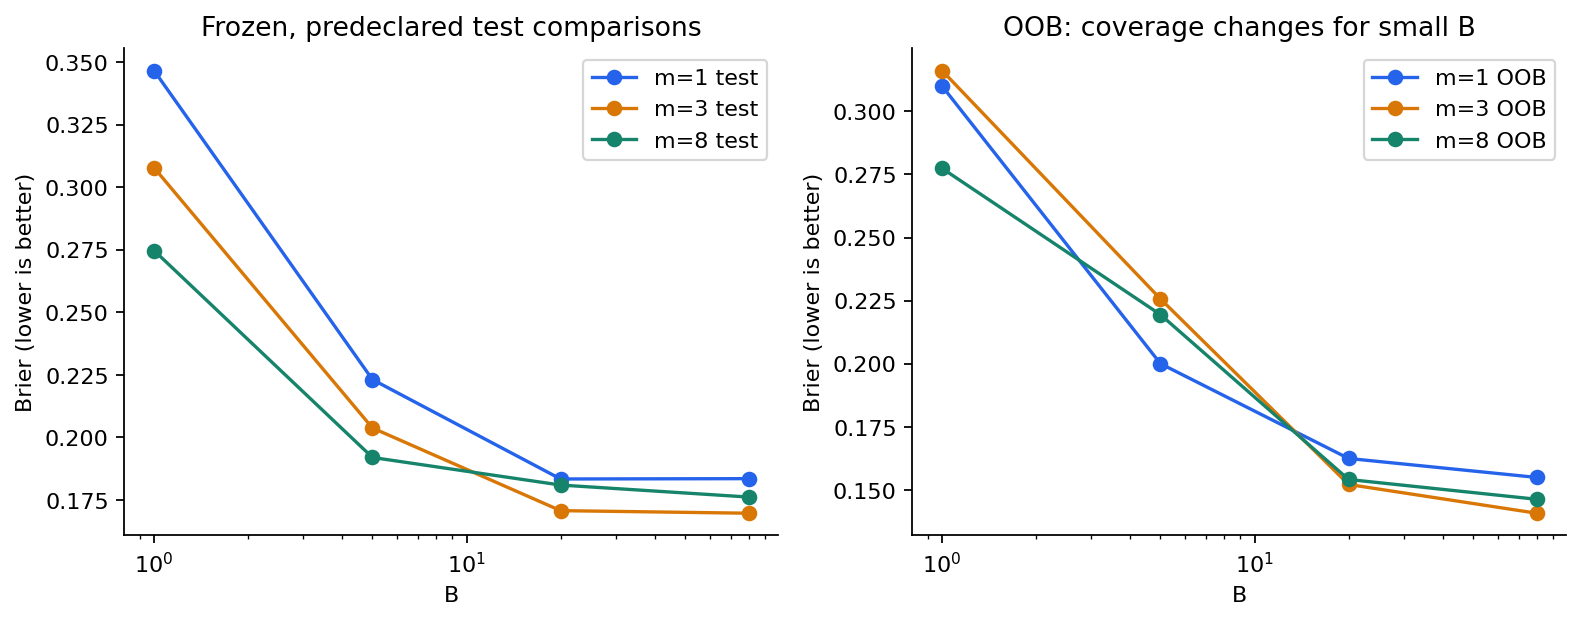

04_oob_coverage.png


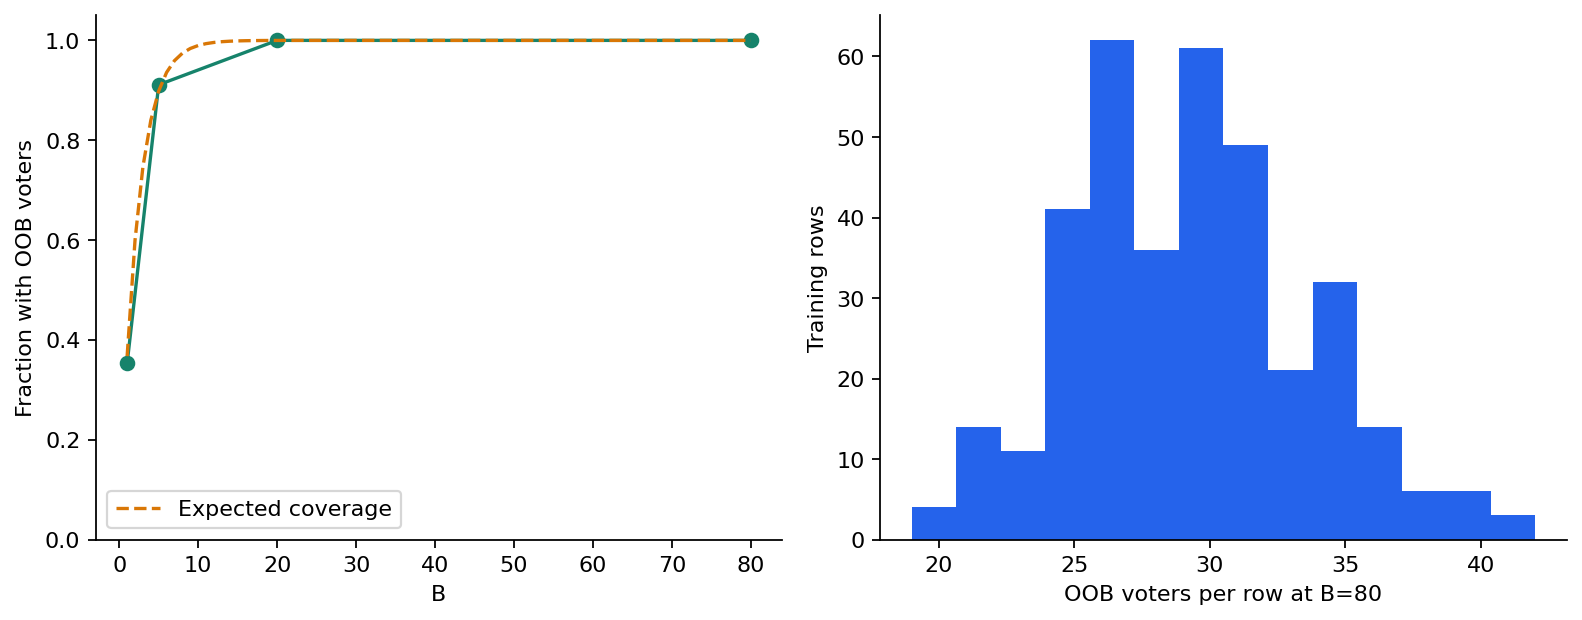

05_feature_tradeoff.png


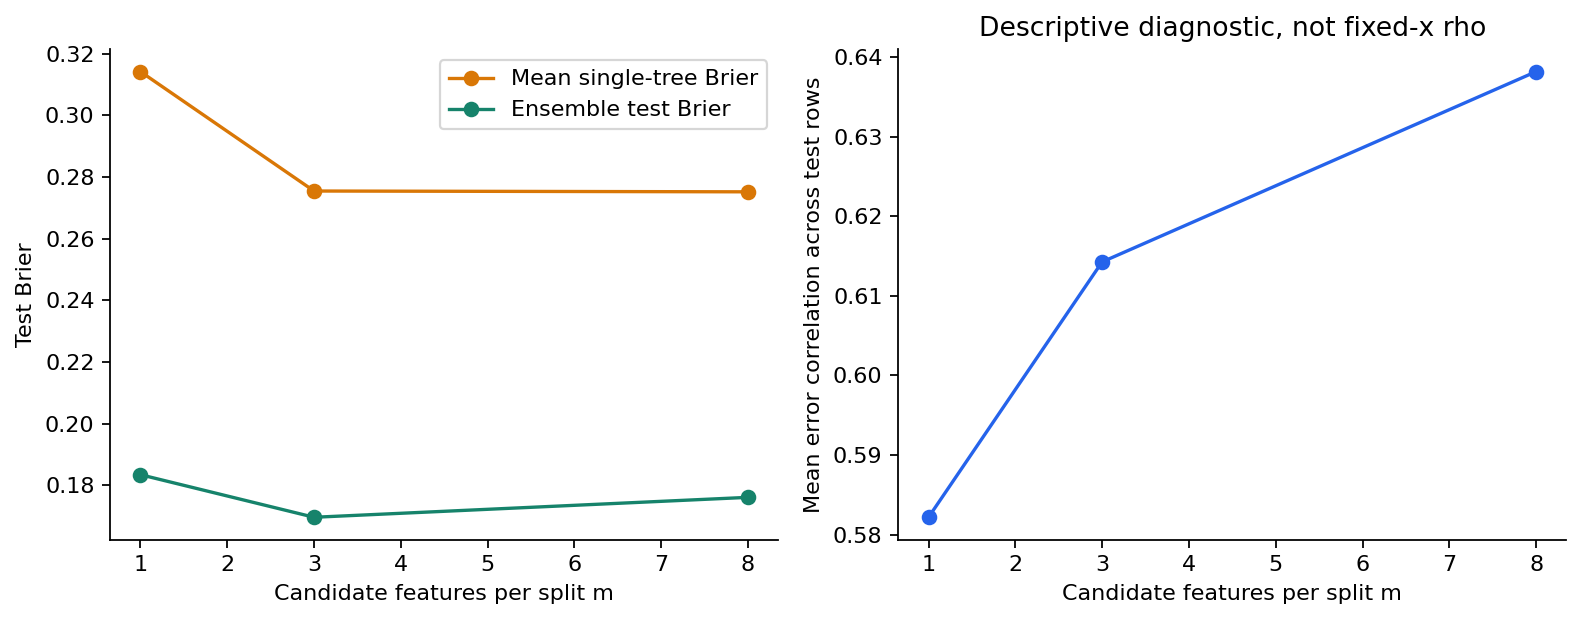

06_group_counterexample.png


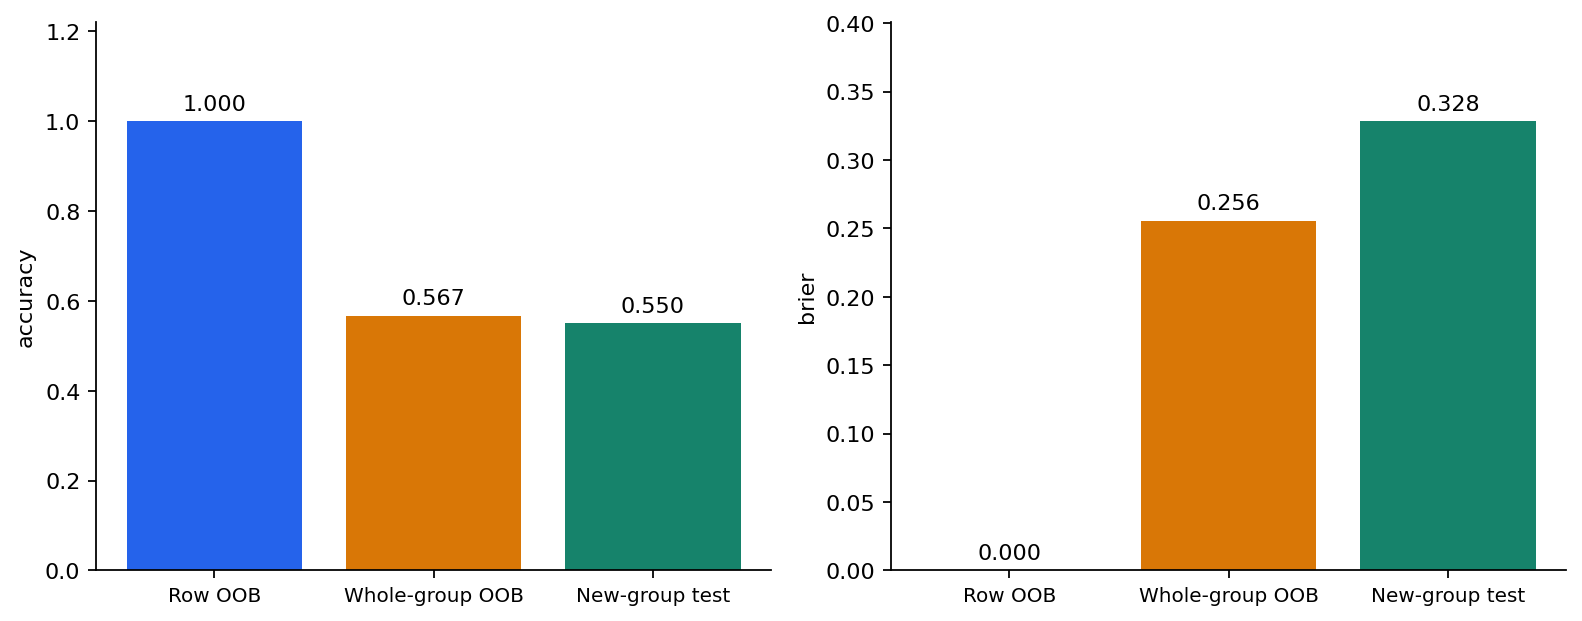

In [5]:
from plots import build
from IPython.display import display,Image
build(result,'outputs/notebook-figures')
for file in sorted(Path('outputs/notebook-figures').glob('*.png')):
    print(file.name)
    display(Image(filename=str(file)))

## 新组泛化反例
行级袋外不保证整个对象未见。核对同组旁路比例以及整组OOB。

In [6]:
result['group_counterexample']

{'row_oob': {'accuracy': 1.0, 'brier': 0.0001191201204120733},
 'new_group_test': {'accuracy': 0.55, 'brier': 0.3283151041666667},
 'group_oob': {'accuracy': 0.5666666666666667, 'brier': 0.2556691994533788},
 'group_oob_coverage': 1.0,
 'row_oob_sibling_fraction': 0.9937529578797918,
 'row_oob_count': 10565,
 'oob_with_sibling': 10499,
 'train_groups': 60,
 'test_groups': 60,
 'rows_per_group': 6}

## 让错误报告真正失败
修改副本的袋外分母，检查程序应拒绝。原发布报告保持不变。

In [7]:
import copy
bad=copy.deepcopy(result)
bad['ensembles']['3']['oob'][0]['counts'][0]+=1
try:
    audit(bad)
except RuntimeError as error:
    print('Expected rejection:',error)
else:
    raise RuntimeError('Tampered report was not rejected')

Expected rejection: FAILED: m3 B1 OOB counts


## 收束
完成lab.md的12题，特别区分软投票、OOB的逐行分母、共同偏差与群组评价目标。